In [4]:
# Importing libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px


# EXTRACTING AND FILTERING THE DATASETS

First step is to extract one of the datasets used for this project from a geopackage database

In [6]:
pip install geopandas

In [7]:
import geopandas as gpd

data = gpd.read_file("prodes_amazonia_nb2.gpkg")


C:\Users\danie\anaconda3\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'prodes_amazonia_nb2.gpkg': 'accumulated_deforestation_2000_nf_biome' (default), 'no_forest_biome', 'residual_biome', 'yearly_deforestation_biome', 'hydrography_biome', 'accumulated_deforestation_2007_biome', 'yearly_deforestation_nf_biome', 'hydrography_nf_biome', 'residual_nf_biome', 'yearly_deforestation_smaller_than_625ha_biome'. Specify layer parameter to avoid this warning.
  result = read_func(


In [8]:
data = gpd.read_file("prodes_amazonia_nb2.gpkg", layer="yearly_deforestation_nf_biome")

In [9]:
df = data.drop(columns="geometry")
df.to_csv("prodes_amazon_legal.csv", index=False)

Secondly, I filtered the brazil beef dataset to extract only the region that we are focusing for this project

In [11]:
livestock = pd.read_csv("brazil_beef_v2_2_1.csv")

In [12]:
livestock['biome'].unique()

array(['AMAZONIA', 'CAATINGA', 'CERRADO', 'MATA ATLANTICA', 'PAMPA',
       'PANTANAL', 'UNKNOWN'], dtype=object)

In [13]:
livestock = livestock[
    livestock['biome'].str.strip().str.upper() == 'AMAZONIA'
]

In [14]:
livestock.to_csv("beef_amazon.csv", index=False)

# EDA( EXPLORATORY DATA ANALYSIS)

## IMPORTING THE DATASETS

In [17]:
deforestation_df = pd.read_csv("prodes_amazon_legal.csv")
beef_df = pd.read_csv("beef_amazon.csv")
co2_df = pd.read_excel("inpe_EM_BRAmz_results.xlsx", sheet_name = "Com degradação", skiprows=10)

In [18]:
deforestation_df.head()

,state,path_row,main_class,class_name,def_cloud,julian_day,image_date,year,area_km,scene_id,source,satellite,sensor,uuid
0,MT,22871,desmatamento,d2023,0.0,259,2023-09-16,2023,0.030756,10329.0,Amazonia - Nao Floresta,Sentinel-2,MSI,bd04328e-979a-4706-94e9-7b5a7ec2b15b
1,AP,22560,desmatamento,d2002,NaN,232,2002-08-20,2002,5.214920,NaN,Amazônia,LANDSAT8,OLI,68272938-3419-462c-b112-101c1ba38c6b
2,MT,22871,desmatamento,d2008,NaN,230,2008-08-17,2008,0.111416,NaN,Amazônia,LANDSAT8,OLI,84d395b0-999a-4319-854e-37f6370a7bae
3,MT,21016,desmatamento,d2024,0.0,256,2024-09-12,2024,0.013637,10610.0,Amazonia - Nao Floresta,Sentinel-2,MSI,cfc86599-70eb-4486-bea5-3186786b5039
4,AM,22962,desmatamento,d2004,NaN,290,2004-10-16,2004,0.144495,NaN,Amazônia,LANDSAT8,OLI,809bafdc-4dfd-45f7-8cd8-7490795d3391


In [19]:
beef_df.head()

,year,country_of_production,biome,state_of_production,state_of_production_trase_id,municipality_of_production,municipality_of_production_trase_id,logistics_hub,product_type,port_of_export,...,country_of_destination,economic_bloc,country_of_production_trase_id,country_of_destination_trase_id,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
0,2011,BRAZIL,AMAZONIA,ACRE,BR-12,BUJARI,BR-1200138,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.689217,2763.220500
1,2011,BRAZIL,AMAZONIA,ACRE,BR-12,RIO BRANCO,BR-1200401,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.975922,3912.684851
2,2011,BRAZIL,AMAZONIA,ACRE,BR-12,SENADOR GUIOMARD,BR-1200450,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,0.697649,2797.025472
3,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,BOCA DO ACRE,BR-1300706,UNKNOWN,BEEF OFFALS,SANTOS,...,CHINA (HONG KONG),CHINA (HONG KONG),BR,HK,NaN,NaN,NaN,NaN,11.786114,39216.614533
4,2011,BRAZIL,AMAZONIA,AMAZONAS,BR-13,LABREA,BR-1302405,JARU,BEEF BONELESS,ITAJAA,...,RUSSIAN FEDERATION,RUSSIAN FEDERATION,BR,RU,NaN,NaN,NaN,NaN,1.119702,3395.156400


In [20]:
co2_df.head()

,Year,D_AreaAcc,D_Area,DEGRAD_Area,-,VR_CO2_1stOrder,VR_CO2_2ndOrder,SV_CO2Emission,SV_CO2Absorption,-.1,DEGRAD_CO2Emission,DEGRAD_CO2Absorption,-.2,NET_1st_Order,NET_2nd_Order
0,1960,842754,842754,0,-,411,133,0,0,-,0,0,-,411,133
1,1961,1685508,842754,0,-,411,222,0,0,-,0,0,-,411,222
2,1962,2528262,842754,0,-,411,276,0,0,-,0,0,-,411,276
3,1963,3371016,842754,0,-,411,311,0,-2,-,0,0,-,409,309
4,1964,4213770,842754,0,-,411,334,0,-4,-,0,0,-,407,329


In [21]:
deforestation_df['year'].unique()

array([2023, 2002, 2008, 2024, 2004, 2018, 2020, 2021, 2006, 2016, 2019,
       2014, 2022, 2013, 2010], dtype=int64)

In [22]:
beef_df['year'].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021, 2022,
       2023], dtype=int64)

In [23]:
co2_df['Year'].unique()

array([1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016, 2017, 2018, 2019, 2020], dtype=int64)

In [24]:
deforestation_df.dtypes

state          object
path_row        int64
main_class     object
class_name     object
def_cloud     float64
julian_day      int64
image_date     object
year            int64
area_km       float64
scene_id      float64
source         object
satellite      object
sensor         object
uuid           object
dtype: object

In [25]:
beef_df.dtypes

year                                                                int64
country_of_production                                              object
biome                                                              object
state_of_production                                                object
state_of_production_trase_id                                       object
municipality_of_production                                         object
municipality_of_production_trase_id                                object
logistics_hub                                                      object
product_type                                                       object
port_of_export                                                     object
exporter                                                           object
exporter_group                                                     object
zero_deforestation_brazil_beef                                     object
forest_500_beef                       

In [26]:
co2_df.dtypes

Year                     int64
D_AreaAcc                int64
D_Area                   int64
DEGRAD_Area              int64
-                       object
VR_CO2_1stOrder          int64
VR_CO2_2ndOrder          int64
SV_CO2Emission           int64
SV_CO2Absorption         int64
-.1                     object
DEGRAD_CO2Emission       int64
DEGRAD_CO2Absorption     int64
-.2                     object
NET_1st_Order            int64
NET_2nd_Order            int64
dtype: object

In [27]:
deforestation_df.shape

(117177, 14)

In [28]:
beef_df.shape

(839727, 26)

In [29]:
co2_df.shape

(61, 15)

In [30]:
deforestation_df.duplicated().sum()

0

In [31]:
beef_df.duplicated().sum()

0

In [32]:
co2_df.duplicated().sum()

0

In [33]:
deforestation_df.isnull().sum()

state              0
path_row           0
main_class         0
class_name         0
def_cloud     107965
julian_day         0
image_date         0
year               0
area_km            0
scene_id      107988
source             0
satellite          0
sensor             0
uuid               0
dtype: int64

In [34]:
beef_df.isnull().sum()

year                                                                   0
country_of_production                                                  0
biome                                                                  0
state_of_production                                                    0
state_of_production_trase_id                                           0
municipality_of_production                                             0
municipality_of_production_trase_id                                    0
logistics_hub                                                          0
product_type                                                           0
port_of_export                                                         0
exporter                                                               0
exporter_group                                                         0
zero_deforestation_brazil_beef                                         0
forest_500_beef                                    

In [35]:
co2_df.isnull().sum()

Year                    0
D_AreaAcc               0
D_Area                  0
DEGRAD_Area             0
-                       0
VR_CO2_1stOrder         0
VR_CO2_2ndOrder         0
SV_CO2Emission          0
SV_CO2Absorption        0
-.1                     0
DEGRAD_CO2Emission      0
DEGRAD_CO2Absorption    0
-.2                     0
NET_1st_Order           0
NET_2nd_Order           0
dtype: int64

### Invalid Entries

In [91]:
beef_df['importer'].astype(str).str.contains('"', na=False).sum()

1450

In [93]:
beef_df['importer'].str.contains('&#', na=False).sum()

193

In [36]:
deforestation_df.describe()

,path_row,def_cloud,julian_day,year,area_km,scene_id
count,117177.000000,9212.0,117177.000000,117177.000000,117177.000000,9189.000000
mean,22604.030245,0.0,244.723461,2011.732507,0.148804,10451.843073
std,2173.674931,0.0,41.729522,7.432707,0.622272,154.620532
min,158.000000,0.0,15.000000,2002.000000,0.000020,10242.000000
25%,22567.000000,0.0,224.000000,2004.000000,0.019603,10319.000000
50%,22871.000000,0.0,240.000000,2010.000000,0.038777,10424.000000
75%,23068.000000,0.0,270.000000,2019.000000,0.094432,10523.000000
max,33008.000000,0.0,361.000000,2024.000000,53.043873,10775.000000


In [37]:
beef_df.describe()

,year,cattle_deforestation_5_year_total_exposure,co2_gross_emissions_cattle_deforestation_5_year_total_exposure,co2_net_emissions_cattle_deforestation_5_year_total_exposure,land_use,volume,fob
count,839727.000000,630603.000000,6.306030e+05,6.306030e+05,808268.000000,839727.000000,8.397270e+05
mean,2017.910960,3.152878,1.431608e+03,1.319155e+03,114.752244,7.560965,2.547733e+04
std,3.810633,32.922416,1.658885e+04,1.541352e+04,548.265643,34.026620,1.205131e+05
min,2011.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.299620,1.483560e+02
25%,2015.000000,0.118720,4.290230e+01,3.834555e+01,13.955774,1.014637,3.241834e+03
50%,2019.000000,0.440201,1.697448e+02,1.537368e+02,28.407606,1.938585,6.313568e+03
75%,2021.000000,1.526267,6.197420e+02,5.642000e+02,73.893583,4.911512,1.625017e+04
max,2023.000000,8432.792534,4.252106e+06,3.972162e+06,100000.437286,4278.000019,1.586512e+07


In [38]:
co2_df.describe()

,Year,D_AreaAcc,D_Area,DEGRAD_Area,VR_CO2_1stOrder,VR_CO2_2ndOrder,SV_CO2Emission,SV_CO2Absorption,DEGRAD_CO2Emission,DEGRAD_CO2Absorption,NET_1st_Order,NET_2nd_Order
count,61.000000,6.100000e+01,6.100000e+01,6.100000e+01,61.000000,61.000000,61.000000,61.000000,61.00000,61.000000,61.000000,61.000000
mean,1990.000000,3.746415e+07,1.324505e+06,4.035045e+05,653.622951,616.196721,48.704918,-86.032787,81.52459,-54.590164,643.163934,605.688525
std,17.752934,2.365221e+07,6.324252e+05,7.129856e+05,302.902634,260.263701,45.004201,61.896410,146.53755,84.977718,308.937004,270.875097
min,1960.000000,8.427540e+05,4.571000e+05,0.000000e+00,234.000000,133.000000,0.000000,-185.000000,0.00000,-245.000000,108.000000,133.000000
25%,1975.000000,1.348406e+07,8.427540e+05,0.000000e+00,411.000000,381.000000,7.000000,-143.000000,0.00000,-31.000000,396.000000,366.000000
50%,1990.000000,4.030233e+07,1.103000e+06,1.558720e+05,541.000000,603.000000,39.000000,-81.000000,34.00000,-18.000000,550.000000,667.000000
75%,2005.000000,6.107624e+07,1.822600e+06,1.558720e+05,888.000000,844.000000,83.000000,-28.000000,34.00000,0.000000,880.000000,853.000000
max,2020.000000,6.972315e+07,2.905900e+06,2.741165e+06,1416.000000,1107.000000,138.000000,0.000000,691.00000,0.000000,1380.000000,1053.000000


## DISTRIBUTION OF THE DATA

Histograms were used to better understand how the data is distributed across different variables. 
For CO₂-related variables, the data is highly skewed, with most values concentrated at the lower end and a few very large values. In the deforestation data, most observations are close to zero, with only a small number of higher values. For cattle-related variables, a similar pattern appears, with most values being low and some higher outliers, indicating variation across observations.

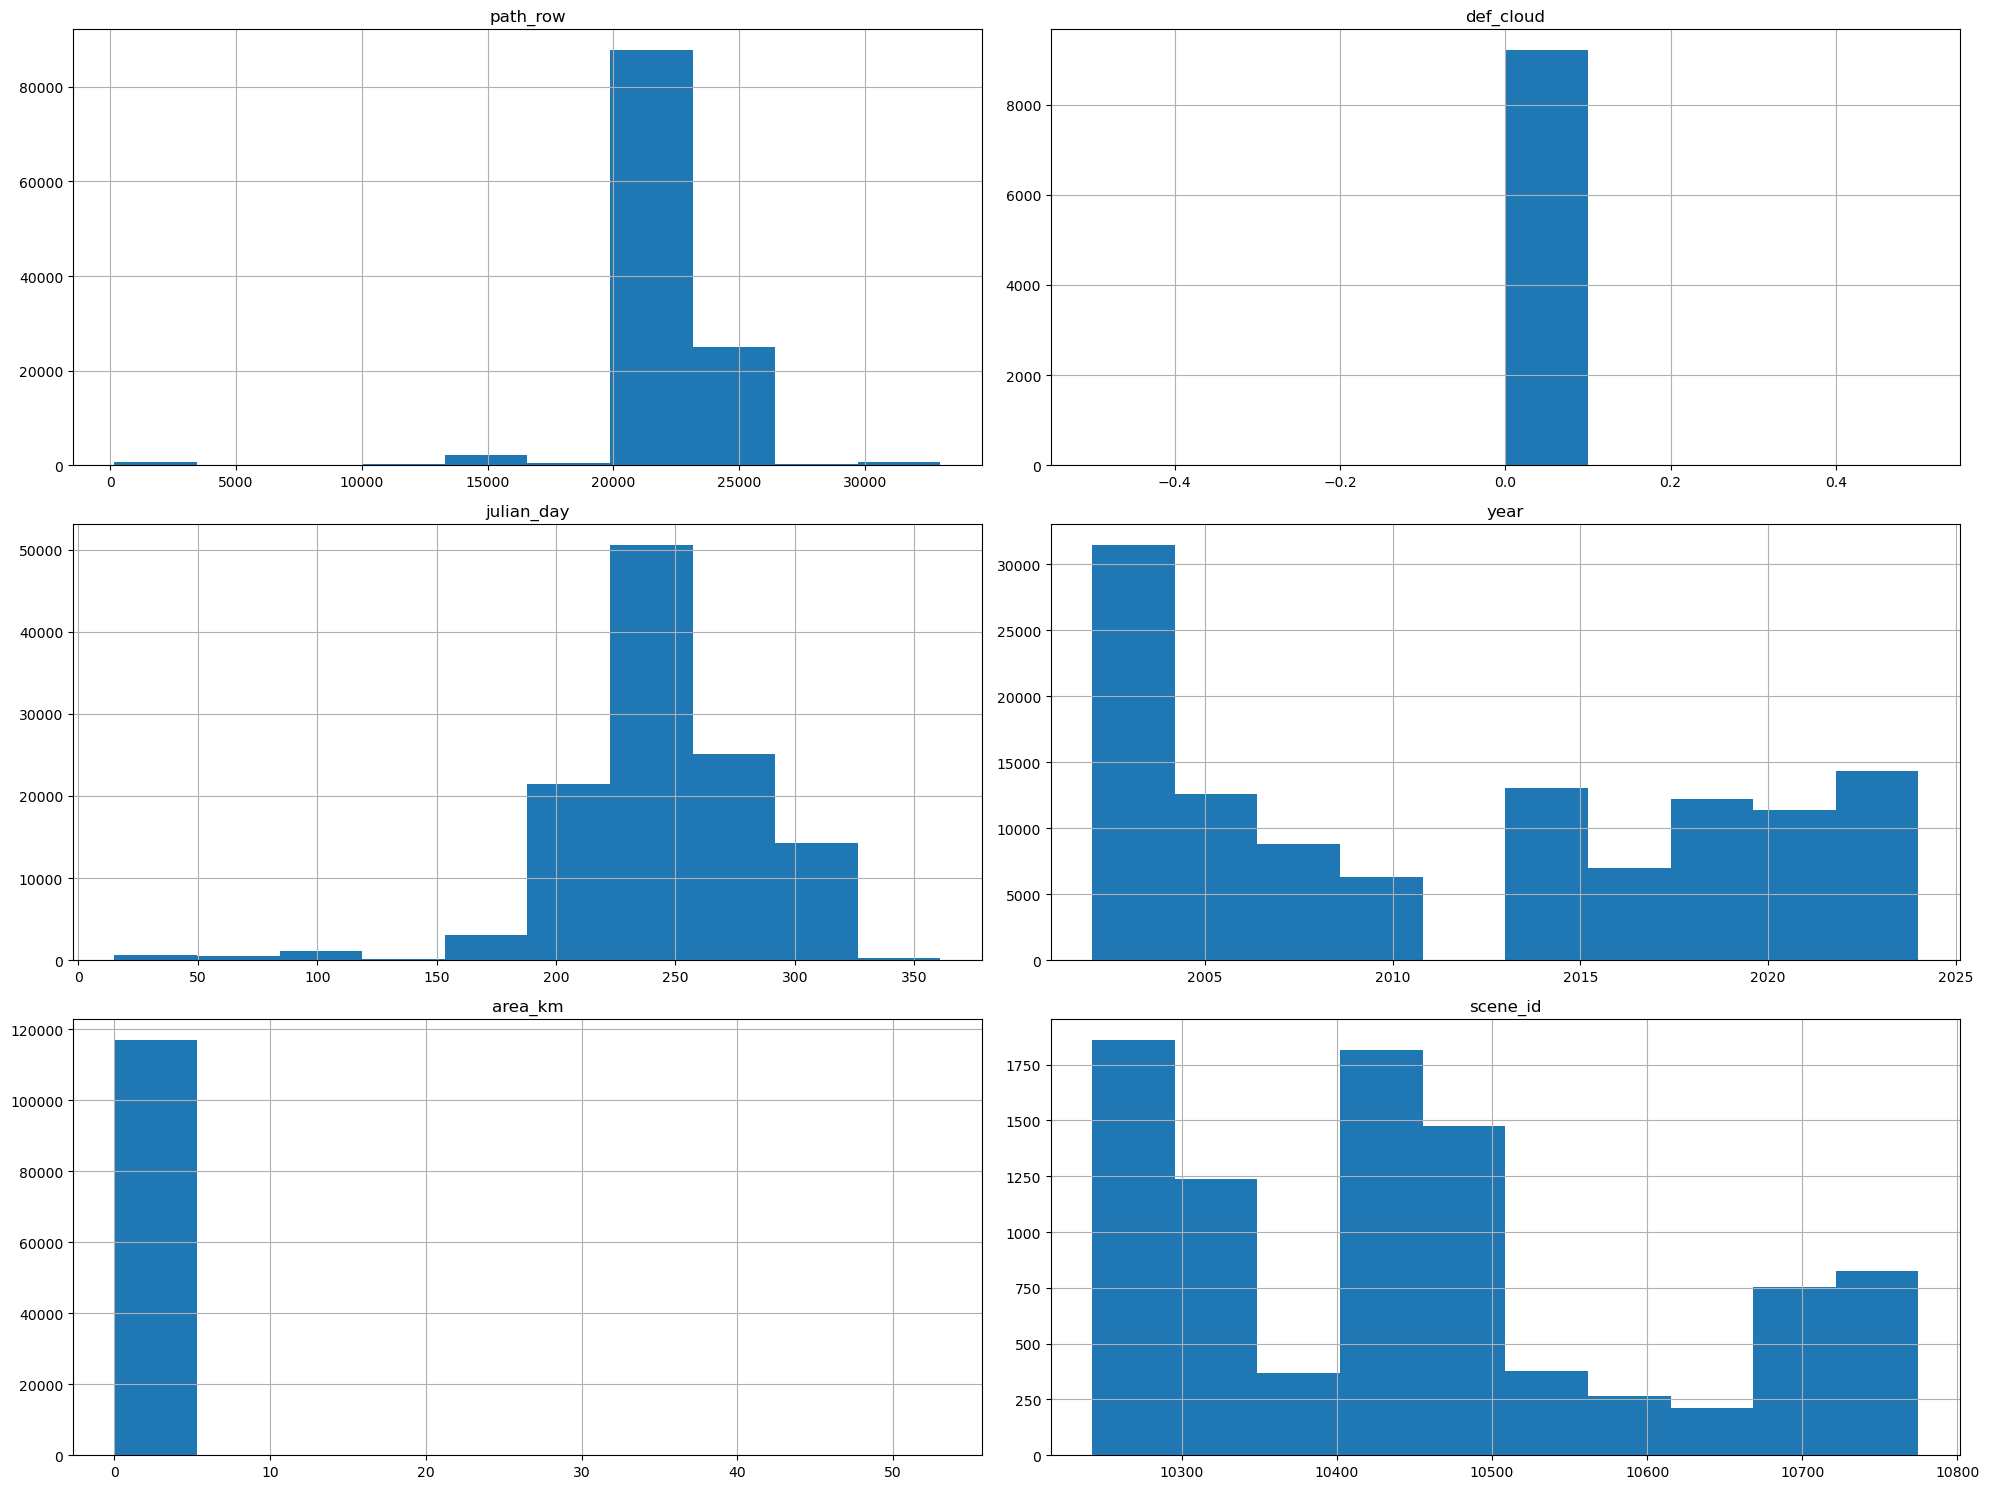

In [40]:
deforestation_df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

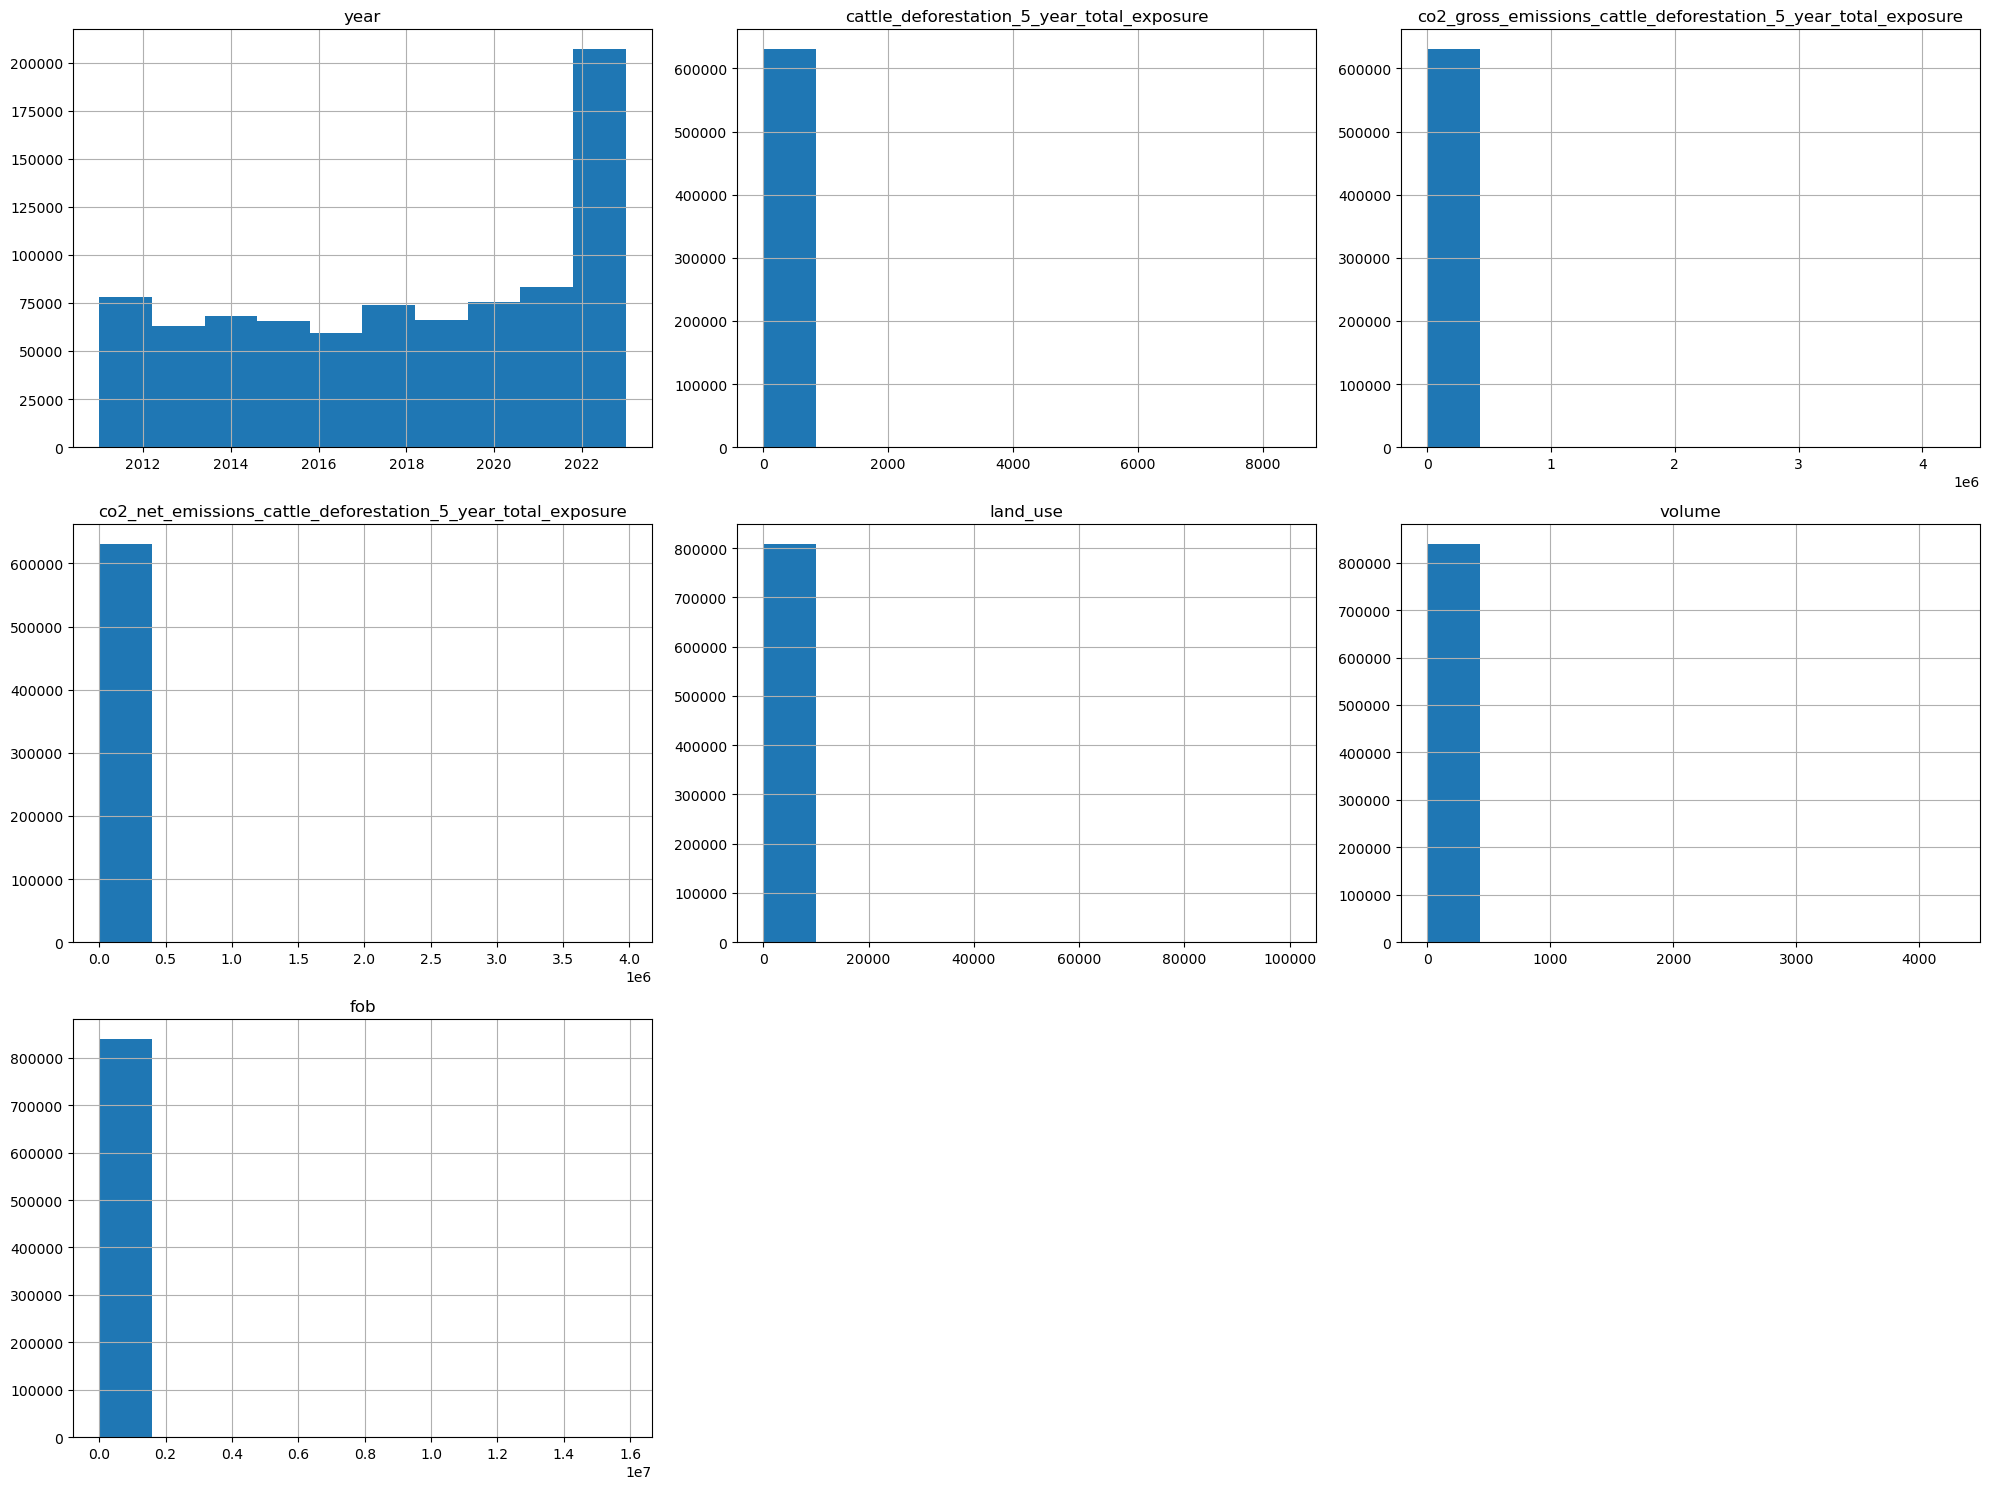

In [41]:
beef_df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

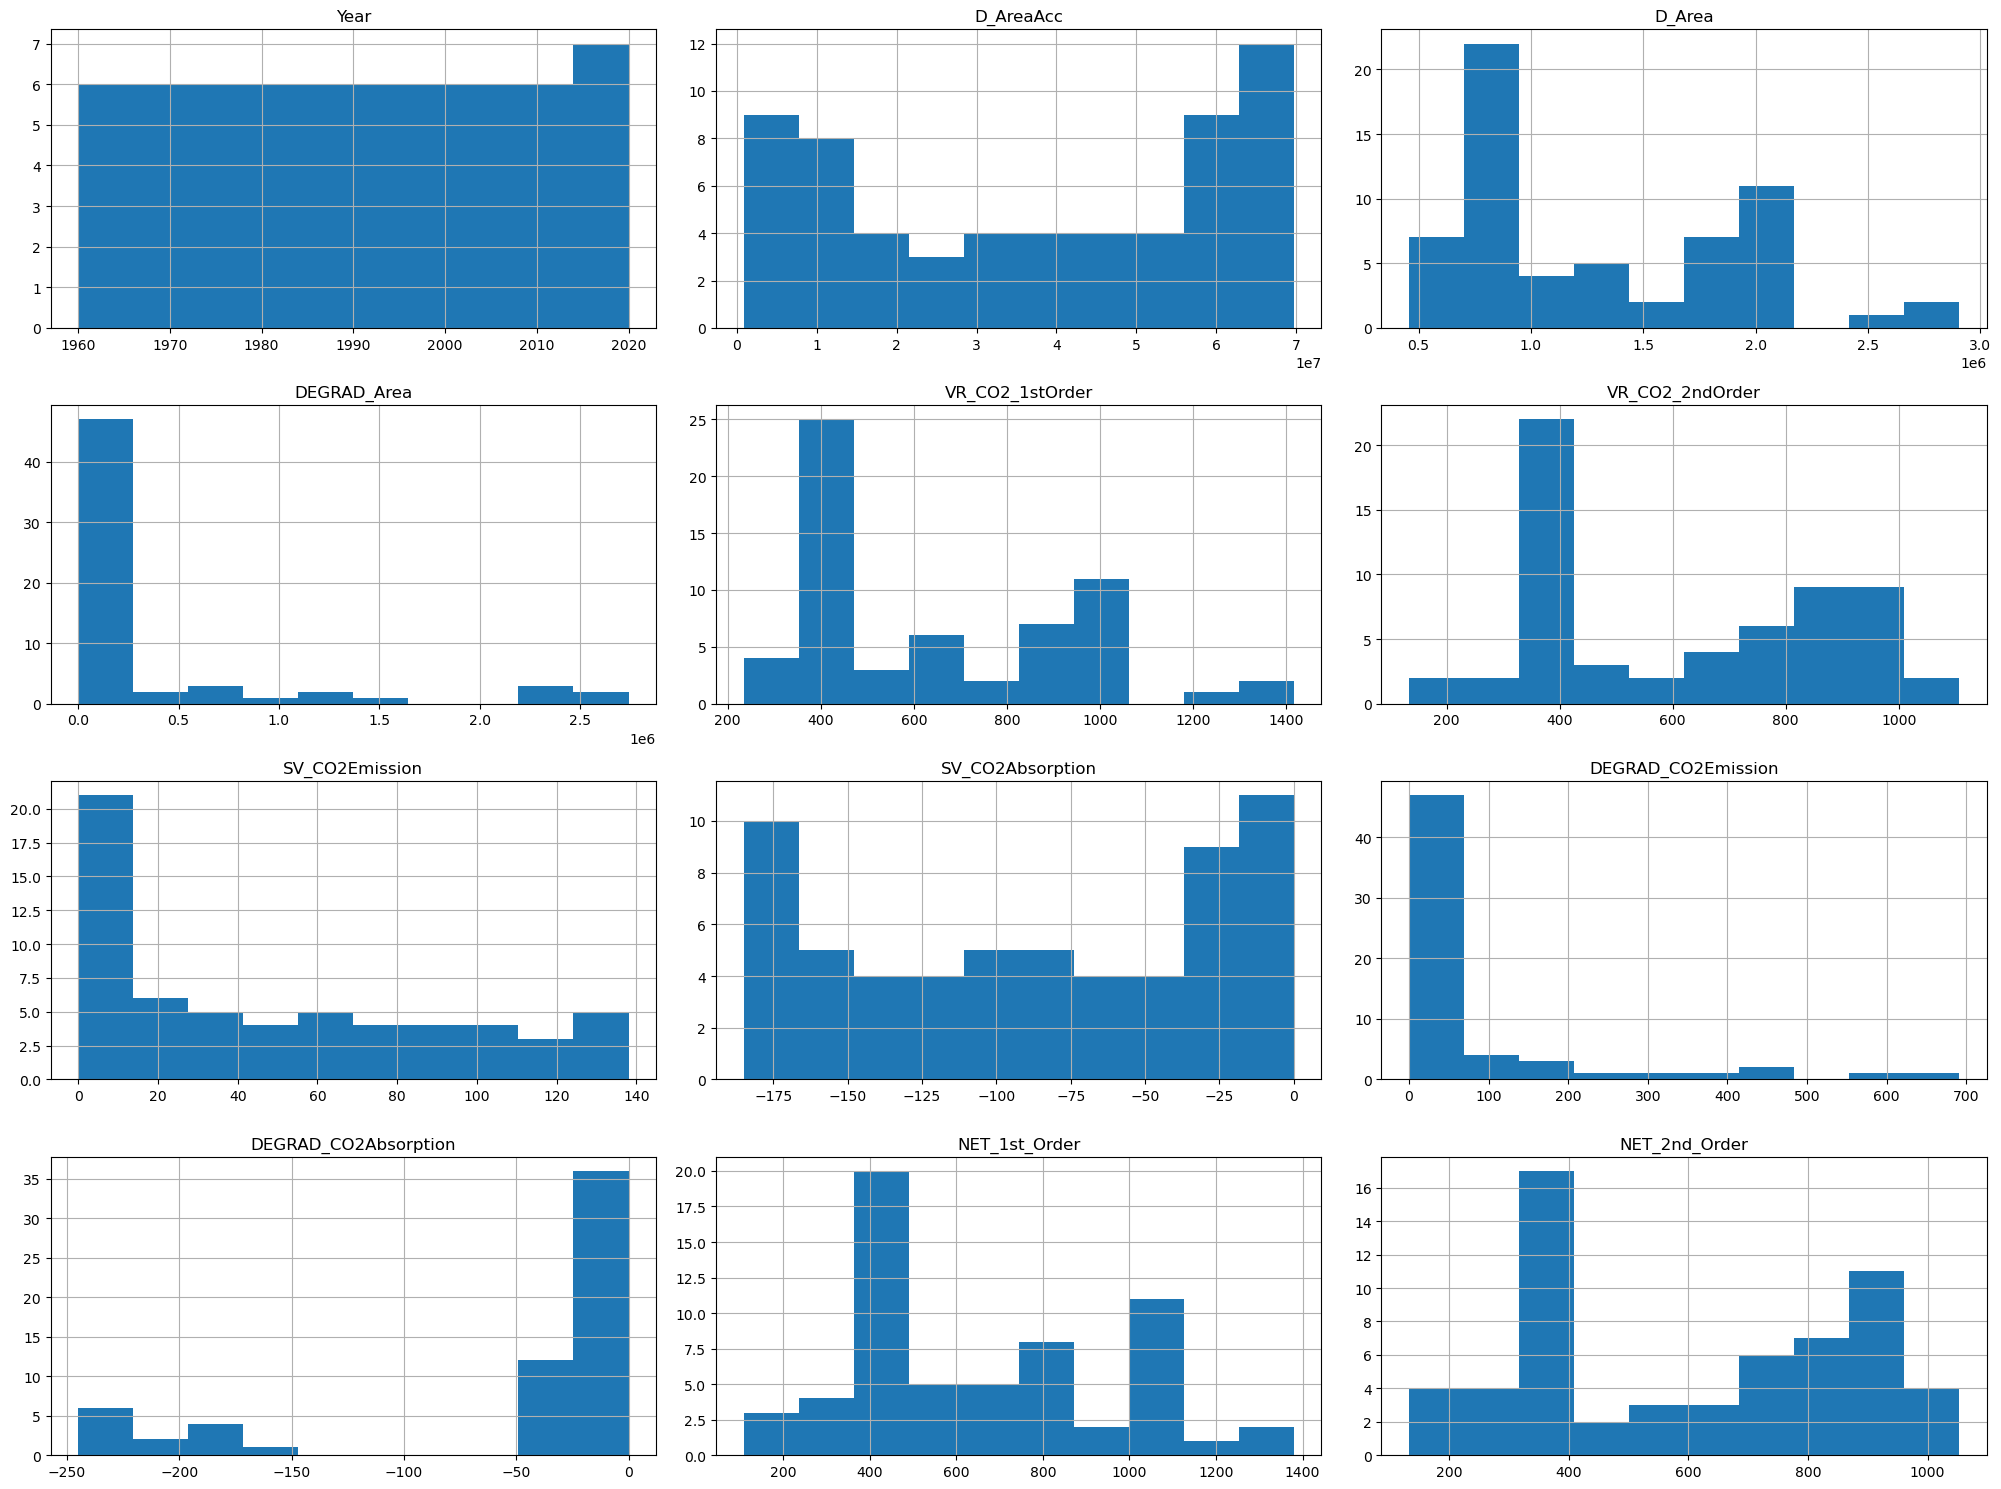

In [42]:
co2_df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

## Checking outliers

Boxplots were used to understand the distribution of the variables and identify extreme values across the datasets.
Boxplot 1 shows that most deforestation values are very close to 0 km², with a few outliers reaching up to around 50 km², indicating a highly skewed distribution.
Boxplot 2 reveals similar skewness across beef-related variables, with extreme outliers in fob above $ 15 million and CO₂ emissions up to 4 million, meaning a small number of cases dominate the data.
Boxplot 3 NET_2nd_Order shows a more balanced distribution, with values roughly between 130 and 1000 and a median around 650, making it easier to interpret typical values.

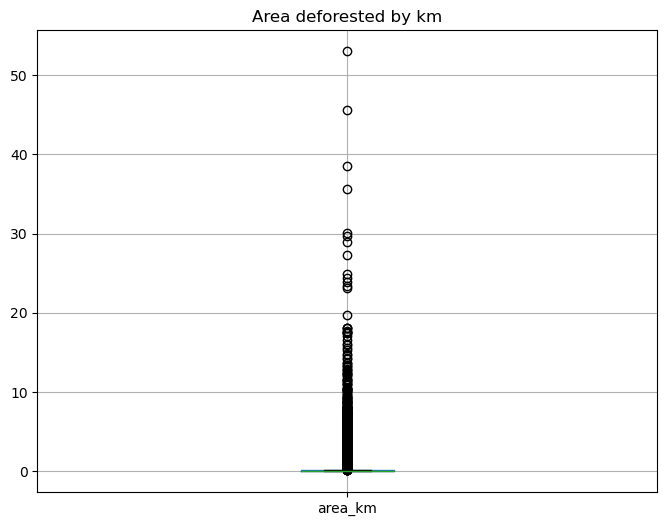

In [44]:
plt.figure(figsize=(8,6))
deforestation_df.boxplot(column=['area_km'])
plt.title('Area deforested by km')
plt.show()

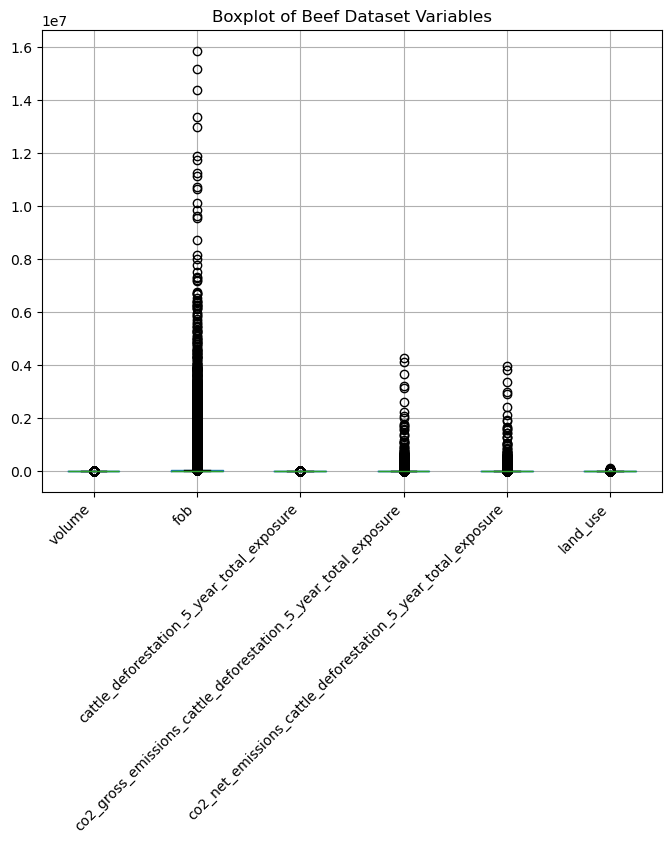

In [45]:
plt.figure(figsize=(8,6))
beef_df.boxplot(column=['volume', 'fob', 'cattle_deforestation_5_year_total_exposure','co2_gross_emissions_cattle_deforestation_5_year_total_exposure','co2_net_emissions_cattle_deforestation_5_year_total_exposure','land_use' ])
plt.xticks(rotation=45, ha='right')
plt.title('Boxplot of Beef Dataset Variables')
plt.show()

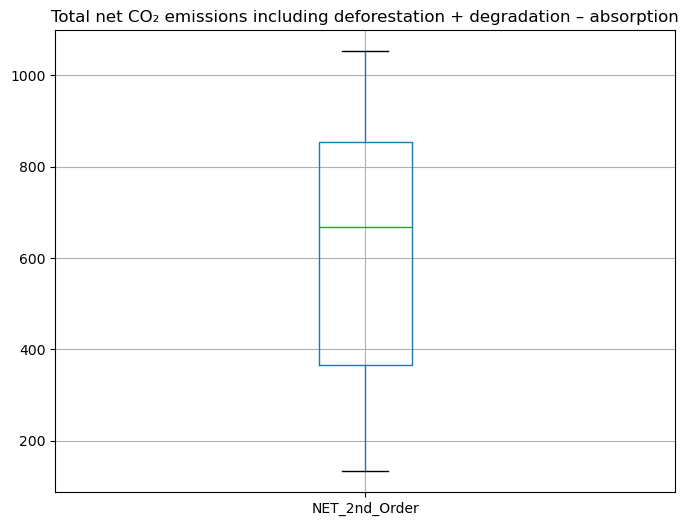

In [46]:
plt.figure(figsize=(8,6))
co2_df.boxplot(column=['NET_2nd_Order'])
plt.title('Total net CO₂ emissions including deforestation + degradation – absorption')
plt.show()

## CHECKING FEATURES RELATIONSHIP
These scatter plots were use to explore how variables behave over time and how they relate to each other. In the first plot year vs area, most values stay below 20 km², with only one clear outlier reaching just above 45 km² around the early 2000s, while more recent years show lower and more stable values. station and CO₂, with values up to around 100,000, and deforestation reaching roughly 8,000.

In [77]:
# fig_2d=px.scatter(deforestation_df,
#            x='year',
#            y='area_km',
#            color='year',
#            size='year',
#            hover_data=['area_km'])
# fig_2d.show()

In the scatter matrix, there is a strong  linear relationship between Volume and FOB, reaching up to about 4,000 (volume) and 15M (fob). Land use also shows a positive relationship with defore.CO₂ gross and net emissions are highly correlated, both exceeding 4 million

In [62]:
# fig_matrix = px.scatter_matrix(
#     beef_df,
#     dimensions=[
#         'volume',
#         'fob',
#         'cattle_deforestation_5_year_total_exposure',
#         'land_use',
#         'co2_gross_emissions_cattle_deforestation_5_year_total_exposure',
#         'co2_net_emissions_cattle_deforestation_5_year_total_exposure'
#     ],
#     labels={
#         'cattle_deforestation_5_year_total_exposure': 'Deforestation_5year',
#         'volume': 'Volume',
#         'fob': 'FOB',
#         'land_use': 'land',
#         'co2_gross_emissions_cattle_deforestation_5_year_total_exposure': 'co2_gross',
#         'co2_net_emissions_cattle_deforestation_5_year_total_exposure': 'co2_net'
#     },
#     color='year'
# )

# fig_matrix.update_layout( width=1070, height=1070)
# fig_matrix.show()

In the final plot, NET CO₂ emissions increase from around 200 in the 1960s to peaks of about 1,100 in the early 2000s, then decline and fluctuate in recent years between 200 and 80

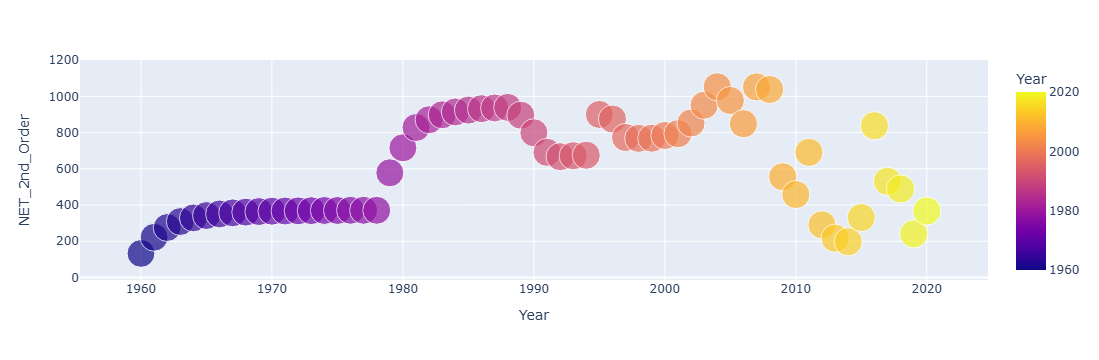

In [52]:
fig_2d=px.scatter(co2_df,
           x='Year',
           y='NET_2nd_Order',
           color='Year',
           size='Year',
           hover_data=['NET_2nd_Order'])
fig_2d.show()

## Simple aggregations

Simple aggregations were used to track how values change over time. Deforestation was highest early on around 3100 km² in 2002 and decreased later. In contrast, beef volume increased from about 223k in 2011 to 690k in 2023, and FOB reached over 2.7 billion, showing economic growth. CO₂ net emissions also rose significantly, reaching over 120 million.

In [54]:
deforestation_df.groupby("year")["area_km"].sum()

year
2002    3103.592468
2004    2760.037609
2006    1882.480304
2008    1163.067041
2010     756.332634
2013    1054.657118
2014     642.272501
2016    1029.121123
2018    1112.089110
2019     679.653633
2020     668.548375
2021     719.338490
2022     726.329228
2023     584.821165
2024     554.039276
Name: area_km, dtype: float64

In [55]:
beef_df.groupby("year")["volume"].sum()

year
2011    223371.898449
2012    428169.688837
2013    609881.468995
2014    599552.803322
2015    483791.314941
2016    462177.754768
2017    582599.476231
2019    505467.315764
2020    624532.444719
2021    502095.163737
2022    636842.113125
2023    690665.151333
Name: volume, dtype: float64

In [56]:
beef_df.groupby("year")["fob"].sum()

year
2011    7.301116e+08
2012    1.414814e+09
2013    1.934537e+09
2014    1.964155e+09
2015    1.387633e+09
2016    1.206347e+09
2017    1.598278e+09
2019    1.648547e+09
2020    2.137257e+09
2021    1.931284e+09
2022    2.696068e+09
2023    2.744971e+09
Name: fob, dtype: float64

In [57]:
beef_df.groupby("year")["co2_net_emissions_cattle_deforestation_5_year_total_exposure"].sum()

year
2011    0.000000e+00
2012    0.000000e+00
2013    0.000000e+00
2014    0.000000e+00
2015    9.314900e+07
2016    8.958171e+07
2017    9.943585e+07
2019    9.643755e+07
2020    1.170607e+08
2021    9.392564e+07
2022    1.156021e+08
2023    1.266708e+08
Name: co2_net_emissions_cattle_deforestation_5_year_total_exposure, dtype: float64

### EDA Conclusions
After conducting an exploratory data analysis (EDA) on the three datasets, it was determined that integrating all of them would not be appropriate for the scope of this project. The primary objective is to predict CO₂ emissions specifically associated with beef production.

The beef dataset alone contains all the relevant features required to support this objective, including variables directly linked to cattle-related deforestation and emissions. Although we initially considered incorporating the area_km variable from the deforestation dataset and the CO₂ column from the emissions dataset, further analysis revealed a critical limitation.

Deforestation and CO₂ datasets represent aggregate values, containing multiple sources beyond beef production. As a result, including these variables would introduce noise and reduce the focus of the model, as they do not isolate deforestation or emissions caused only by cattle-related activities.

Therefore, to maintain the  relevance of the predictive model, the decision was made to rely exclusively on the beef dataset, which provides targeted and domain-specific information aligned with the research objective

# DATA PREPARATION

### Removing Invalid entries

In [96]:
beef_df["importer"] = beef_df["importer"].astype(str).str.replace('&#', '', regex=False)

In [98]:
beef_df["importer"] = beef_df["importer"].astype(str).str.replace('"', '', regex=False)

In [100]:
beef_df["importer"].astype(str).str.contains('"', na=False).sum()

0

In [102]:
beef_df["importer"].str.contains('&#', na=False).sum()

0